In [1]:
#DATA COLLECTION & ENRICHMENT: Merging the Music & Mental Health survey with Spotify audo features

import pandas as pd
import numpy as np

survey = pd.read_csv('mxmh_survey_results.csv')
spotify = pd.read_csv('dataset.csv')

#Checking the rows and cols of the data
print(f'Survey: {survey.shape}') 
print(f'Spotify: {spotify.shape}')
#survey.head()
spotify.head()



Survey: (736, 33)
Spotify: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
#CHECKING FOR THE GENRES EXISTED IN EACH DATASET

print("Survey genres:" , survey['Fav genre'].unique())
print("\nSpotify genres:", spotify['track_genre'].unique())

Survey genres: ['Latin' 'Rock' 'Video game music' 'Jazz' 'R&B' 'K pop' 'Country' 'EDM'
 'Hip hop' 'Pop' 'Rap' 'Classical' 'Metal' 'Folk' 'Lofi' 'Gospel']

Spotify genres: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-p

In [3]:
# Audio features per genre from spotify dataset
audio_features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'instrumentalness', 'speechiness']
genre_profiles = spotify.groupby('track_genre')[audio_features].mean()
print(genre_profiles)

             danceability    energy   valence       tempo  acousticness  \
track_genre                                                               
acoustic         0.549593  0.435368  0.424023  119.010624      0.566816   
afrobeat         0.669580  0.702812  0.698619  119.213337      0.270860   
alt-rock         0.534493  0.754173  0.518260  124.634404      0.122162   
alternative      0.559927  0.720030  0.495570  122.232394      0.147820   
ambient          0.367867  0.237162  0.167498  111.113129      0.776790   
...                   ...       ...       ...         ...           ...   
techno           0.684348  0.746413  0.321878  128.255482      0.081414   
trance           0.583409  0.845272  0.276881  133.276726      0.035870   
trip-hop         0.634695  0.622363  0.478069  118.743616      0.225615   
turkish          0.616077  0.609804  0.462314  120.367607      0.321125   
world-music      0.414572  0.532987  0.250295  121.393711      0.299547   

             instrumenta

In [4]:
#create a dict so that I can map the survey genres to spotify genres
genre_map = {
    'Latin':            'latin',
    'Rock':             'rock',
    'Video game music': 'electronic',   # closest available
    'Jazz':             'jazz',
    'R&B':              'r-n-b',
    'K pop':            'k-pop',
    'Country':          'country',
    'EDM':              'edm',
    'Hip hop':          'hip-hop',
    'Pop':              'pop',
    'Rap':              'hip-hop',      # no 'rap' in Spotify, hip-hop is closest
    'Classical':        'classical',
    'Metal':            'metal',
    'Folk':             'folk',
    'Lofi':             'chill',        # closest available
    'Gospel':           'gospel'
}

#Mapping survey genres to Spotify genre names
survey['spotify_genre'] = survey['Fav genre'].map(genre_map)

# Mergind the features onto survey
merged = survey.merge(genre_profiles, left_on='spotify_genre', right_index=True, how='left')

#debugging for merging
print(f"Merged shape: {merged.shape}")
print(f"Unmapped rows: {merged['spotify_genre'].isna().sum()}")
print(f"Missing audio features: {merged['valence'].isna().sum}")

merged[['Fav genre', 'spotify_genre', 'Anxiety', 'Depression',
        'valence', 'energy', 'danceability']].head(8)






Merged shape: (736, 41)
Unmapped rows: 0
Missing audio features: <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
731    False
732    False
733    False
734    False
735    False
Name: valence, Length: 736, dtype: bool>


,Fav genre,spotify_genre,Anxiety,Depression,valence,energy,danceability
0,Latin,latin,3.0,0.0,0.631149,0.727080,0.721902
1,Rock,rock,7.0,2.0,0.538903,0.679071,0.543609
2,Video game music,electronic,7.0,7.0,0.391839,0.694752,0.652945
3,Jazz,jazz,9.0,7.0,0.490289,0.352954,0.509975
4,R&B,r-n-b,7.0,2.0,0.633164,0.638130,0.614388
5,Jazz,jazz,8.0,8.0,0.490289,0.352954,0.509975
6,Video game music,electronic,4.0,8.0,0.391839,0.694752,0.652945
7,K pop,k-pop,5.0,3.0,0.556915,0.675654,0.647732


In [5]:
#Saving the cleaned at merged data, and cleaning the data
import matplotlib.pyplot as plt
import seaborn as sns

#Dropping the rows where mental health scores are missing
merged = merged.dropna(subset=['Anxiety', 'Depression', 'Insomnia', 'OCD'])
print(f"Clean dataset: {merged.shape[0]} rows")

#Save for later use
merged.to_csv('merged_data.csv', index = False)

Clean dataset: 736 rows


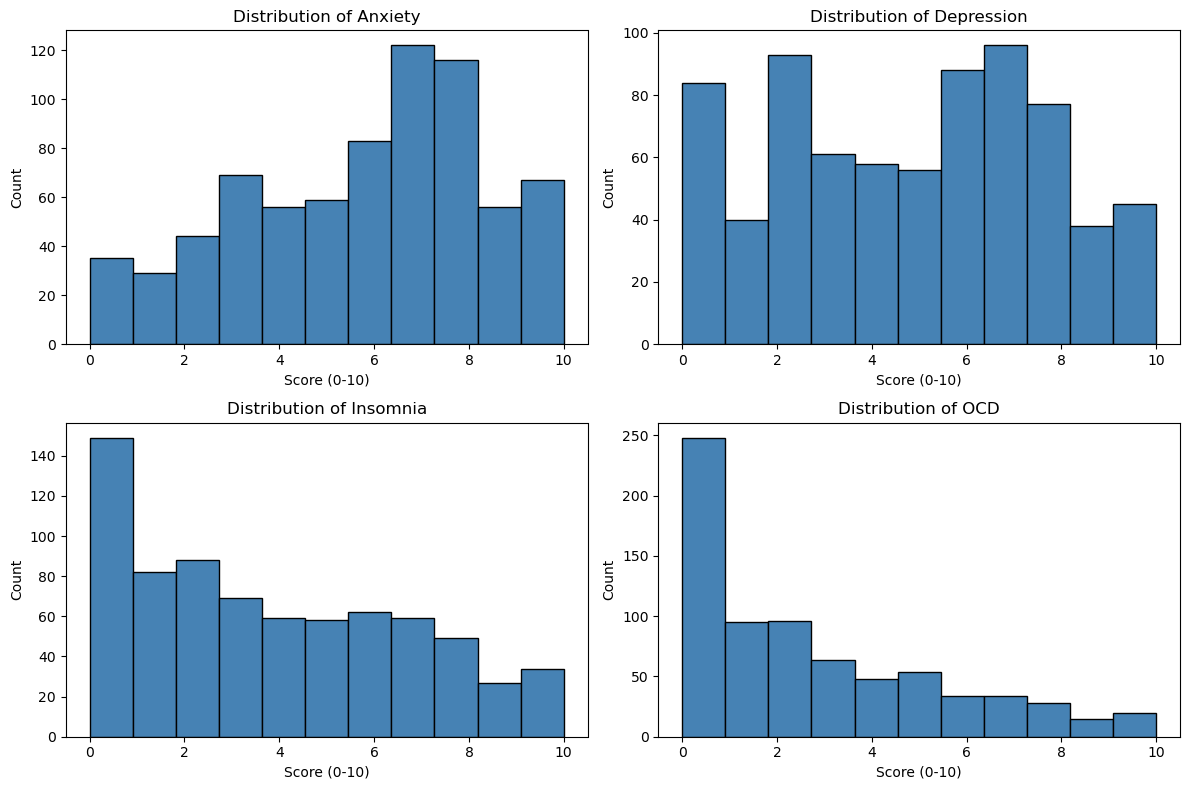

In [6]:
#DISTRIBUTION OF MENTAL HEALTH SCORES WITH HISTOGRAMS
fig, axes = plt.subplots(2,2, figsize=(12,8))
mh_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

for ax, col in zip(axes.flatten(), mh_cols):
    ax.hist(merged[col].dropna(), bins=11, edgecolor='black', color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Score (0-10)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()    



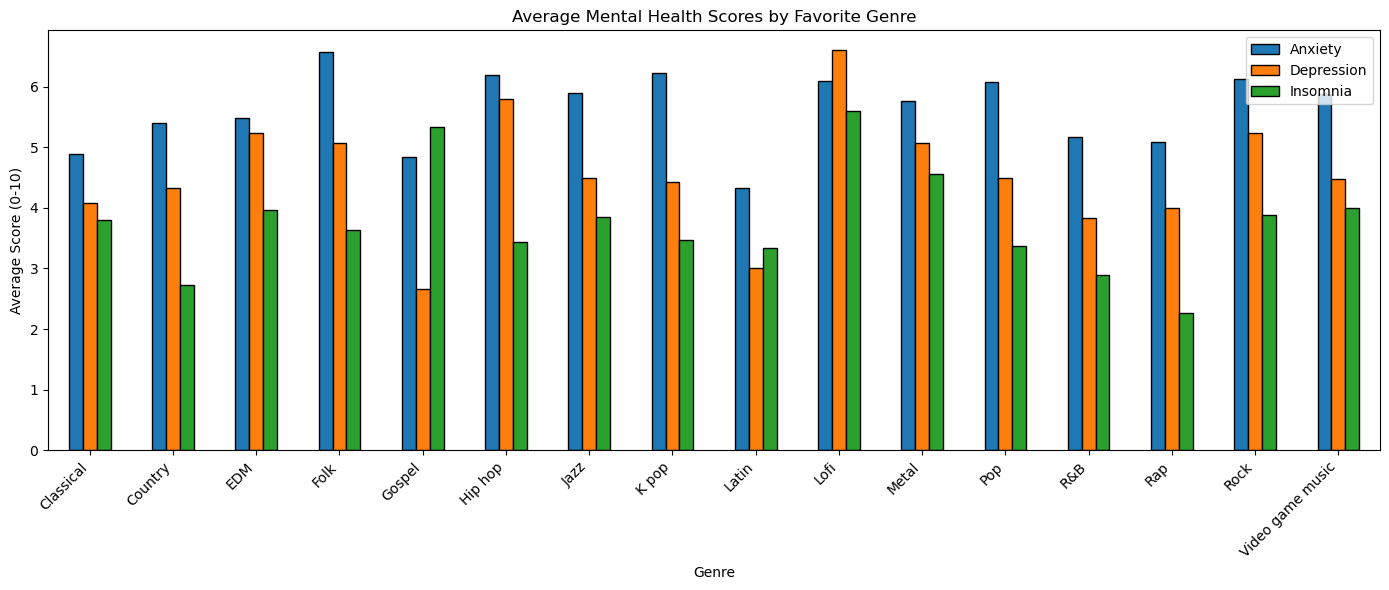

In [7]:
#Average anxiety/depression by favorite genre (bar chart)

genre_mh = merged.groupby('Fav genre')[['Anxiety', 'Depression', 'Insomnia']].mean()

genre_mh.plot(kind = 'bar', figsize=(14,6), edgecolor = 'black')
plt.title('Average Mental Health Scores by Favorite Genre')
plt.xlabel('Genre')
plt.ylabel('Average Score (0-10)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

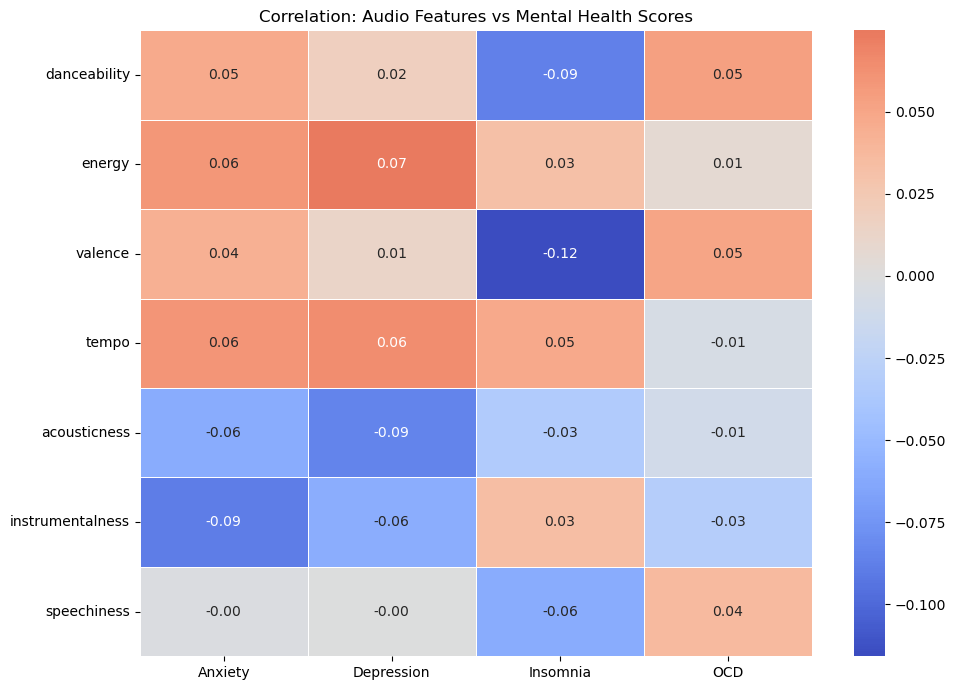

In [8]:
# Correlation heatmap (audio features vs MH scores):

audio_features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'instrumentalness', 'speechiness']
mh_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

corr = merged[audio_features + mh_cols].corr().loc[audio_features, mh_cols]

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,linewidths=0.5)
plt.title('Correlation: Audio Features vs Mental Health Scores')
plt.tight_layout()
plt.show()


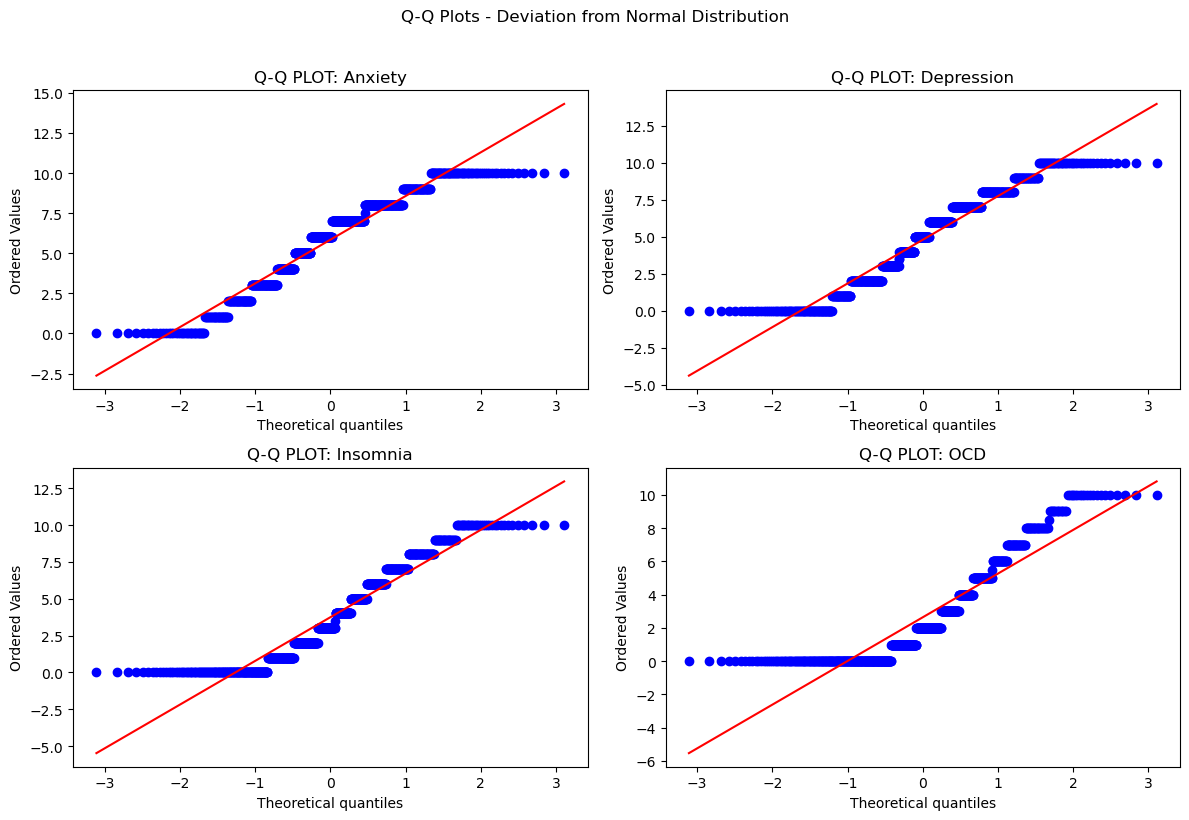

In [9]:
#VISUAL NORMALITY CHECK USING Q-Q plots

import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(2,2, figsize=(12,8))
mh_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

for ax, col in zip(axes.flatten(), mh_cols):
    stats.probplot(merged[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q PLOT: {col}')
plt.suptitle('Q-Q Plots - Deviation from Normal Distribution', y=1.02)
plt.tight_layout()
plt.show()    

In [10]:
# KRUSKAL-WALLIS HYPOTHESIS TEST

print("****** KRUSKAL-WALLIS TEST ******")
print("H0: Anxiety scores are equal across all favorite genres")
print("H1: Anxiety scores are not equal across all favorite genres at least there is one group has\n")


anxiety_groups = []

grouped_data = merged.groupby('Fav genre')

for genre_name, group_data in grouped_data:
    anxiety_scores = group_data['Anxiety'].values
    anxiety_groups.append(anxiety_scores)

stat, p = stats.kruskal(*anxiety_groups)


print(f"H-statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

print("\nResult: ", end="") 
if p < 0.05:
    print("REJECT H0 — genres differ significantly")
else:
    print("FAIL TO REJECT H0")

****** KRUSKAL-WALLIS TEST ******
H0: Anxiety scores are equal across all favorite genres
H1: Anxiety scores are not equal across all favorite genres at least there is one group has

H-statistic: 17.6151
P-value: 0.283444

Result: FAIL TO REJECT H0


In [11]:
# SPEARMAN CORRELATION

print("*** SPEARMAN CORRELATION TEST ***")
print("H0: No monotonic relationship between audio features and mental health scores")
print("H1: A significant monotonic relationship exists\n")

audio_features = ['valence', 'energy', 'danceability', 'acousticness', 'tempo']
targets = ['Anxiety', 'Depression', 'Insomnia']

results = []


for feat in audio_features:
    for target in targets:
        feature_data = merged[feat]
        target_data = merged[target]
        
        # run the Spearman correlation test
        # rho is the correlation coefficient (how strong the link is)
        # p is the p-value (how likely this happened by chance)
        rho, p = stats.spearmanr(feature_data, target_data)
        
        #  checking for statistical significance (p-value less than 0.05)
        if p < 0.05:
            sig = "* significant"
        else:
            sig = ""
            
        current_result = {
            'Feature': feat, 
            'Target': target, 
            'Rho': round(rho, 4), 
            'P-value': round(p, 4), 
            'Result': sig
        }
        
        results.append(current_result)

#displaying
# convert list to panda data frame
results_df = pd.DataFrame(results)

# Print it out as a string, telling Pandas to hide the row numbers (index=False)
print(results_df.to_string(index=False))

*** SPEARMAN CORRELATION TEST ***
H0: No monotonic relationship between audio features and mental health scores
H1: A significant monotonic relationship exists

     Feature     Target     Rho  P-value        Result
     valence    Anxiety  0.0420   0.2548              
     valence Depression  0.0202   0.5848              
     valence   Insomnia -0.1020   0.0056 * significant
      energy    Anxiety  0.0199   0.5902              
      energy Depression  0.0807   0.0286 * significant
      energy   Insomnia  0.0510   0.1666              
danceability    Anxiety  0.0187   0.6127              
danceability Depression  0.0039   0.9152              
danceability   Insomnia -0.0784   0.0335 * significant
acousticness    Anxiety -0.0259   0.4826              
acousticness Depression -0.0869   0.0183 * significant
acousticness   Insomnia -0.0543   0.1415              
       tempo    Anxiety  0.0413   0.2637              
       tempo Depression  0.0594   0.1075              
       tempo  

In [12]:
print("*** MANN-WHITNEY U TEST *** ")
print("H0: Anxiety is equal between people who say music improves vs worsens their mood")
print("H1: There is a difference in anxiety between these two groups\n")

#isolating the data for people who say music 'Improves' their mood

is_improve = merged['Music effects'] == 'Improve'
improve_data = merged[is_improve]

#grab the anxiety column

anxiety_improves_with_blanks = improve_data['Anxiety']

# frop any missing and blank values
anxiety_improves = anxiety_improves_with_blanks.dropna()

# grab the data for people who say music Worsens their mood

is_worsen = merged['Music effects'] == 'Worsen'
worsen_data = merged[is_worsen]

anxiety_worsens_with_blanks = worsen_data['Anxiety']
anxiety_worsens = anxiety_worsens_with_blanks.dropna()

# calculate count and medians for both groups

count_improves = len(anxiety_improves)
median_improves = anxiety_improves.median()
print(f"'Improve' group: n={count_improves}, median={median_improves}")

count_worsens = len(anxiety_worsens)
median_worsens = anxiety_worsens.median()
print(f"'Worsen' group:  n={count_worsens}, median={median_worsens}")

#run the mann whitney u test
stat, p = stats.mannwhitneyu(anxiety_improves, anxiety_worsens, alternative='two-sided')

print(f"\nU-statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

print("\nResult: ", end="")
if p < 0.05:
    print("REJECT H0 — significant difference")
else:
    print("FAIL TO REJECT H0")





*** MANN-WHITNEY U TEST *** 
H0: Anxiety is equal between people who say music improves vs worsens their mood
H1: There is a difference in anxiety between these two groups

'Improve' group: n=542, median=7.0
'Worsen' group:  n=17, median=7.0

U-statistic: 3925.0000
P-value: 0.294861

Result: FAIL TO REJECT H0
